Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland

# Demo 9 - Network Analysis

Today, I'm introducing network analysis with a Python package called [OSMnx](https://osmnx.readthedocs.io/en/stable/) that both downloads and analyzes street networks from OpenStreetMap (OSM). This package was written by Geoff Boeing, now at USC, while he was in grad school, a demonstration of how grad students with an interest in coding can author open-source tools with influence that stretches far beyond their own work.

Beneath the hood, OSMnx relies on a network analysis package called [NetworkX](https://networkx.org/); it's one of the dominant Python tools for storing and analyzing networks, or as mathematicians tend to call them, "graphs."

A network or graph, I'll use these terms interchangeably, is made up of "nodes" or "vertices"—the objects that are related to one another—and "edges" or "links"—connections that define relationships between nodes. In a street network, you can think of the nodes as intersections and the edges as street segments. You could also, however, use a graph to represent more abstract concepts, such as communities. Social network models, for example, use nodes to represent people and edges to represent relationships between them. You could imagine adding attributes to those edges to represent the strength of different relationship (e.g., strong or weak ties), just as length, speed limit, or lane counts along edges in a street network are indicators of connection between two intersections.

The following graph has 6 nodes and edges making direct connections between certain pairs of nodes but not others.

<img alt="basic graph" width=300 src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5b/6n-graf.svg/1920px-6n-graf.svg.png">

We're going to practice analyzing a street network today in terms of shortest paths, a common type of analysis in transportation planning. Another common way of analyzing graphs is based on "degree," the number of nodes connected to a given node. A graph where all nodes are connected to each other would have high "degree centrality," while a graph where nodes are not very well-connected would have low centrality.

Let's install OSMnx, which will automatically install NetworkX as a dependency.

We'll first build a basic graph in NetworkX to demonstrate how it works. Then we'll use OSMnx to download an OSM street network and calculate shortest paths across it.

In [ ]:
# Install OSMNX
# !pip install osmnx

In [1]:
import os
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Build a Basic Graph

Can we build the same graph pictured here in NetworkX?

<img alt="basic graph" width=300 src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5b/6n-graf.svg/1920px-6n-graf.svg.png">

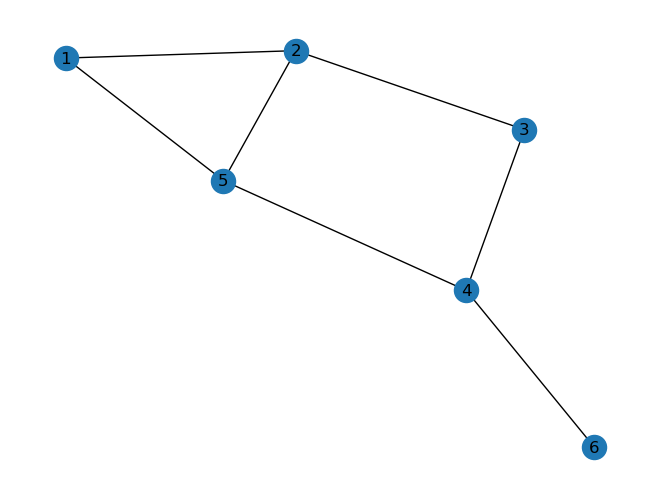

In [2]:
# Create an empty graph
G = nx.Graph()

# Add nodes to the graph
G.add_node(1)
G.add_node(2)
G.add_node(3)
G.add_node(4)
G.add_node(5)
G.add_node(6)

# Add edges between nodes
G.add_edge(1, 2)
G.add_edge(1, 5)
G.add_edge(2, 5)
G.add_edge(2, 3)
G.add_edge(3, 4)
G.add_edge(4, 5)
G.add_edge(4, 6)

# Draw the graph with labels
nx.draw(G, with_labels=True)
plt.show()

In [3]:
# Degrees from a given node
G.degree(1)

2

In [4]:
# Centrality for each vertex
# (degrees / count of other nodes)
nx.degree_centrality(G)

{1: 0.4,
 2: 0.6000000000000001,
 3: 0.4,
 4: 0.6000000000000001,
 5: 0.6000000000000001,
 6: 0.2}

In [5]:
# Average centrality
sum(nx.degree_centrality(G).values()) / len(G.nodes())

0.46666666666666673

In [7]:
# Shortest path
nx.shortest_path(G, 4, 2)

[4, 5, 2]

In [9]:
# help(nx.shortest_path)

# Analyzing a Street Network

## Load a street network from OSM

In [10]:
# Define coordinate systems
UTM18 = 26918
WGS84 = 4326

In [13]:
# help(ox.graph_from_place)

In [15]:
# help(ox.graph_to_gdfs)

In [11]:
# Retrieve the street network for Washington, DC
place = 'Washington, DC, USA'
dc_network_g = ox.graph_from_place(place, network_type='drive')
dc_network_g = ox.project_graph(dc_network_g, to_crs=UTM18)
# Convert to geodataframes for easy plotting and exploration
dc_network_nodes, dc_network_edges = ox.graph_to_gdfs(dc_network_g)

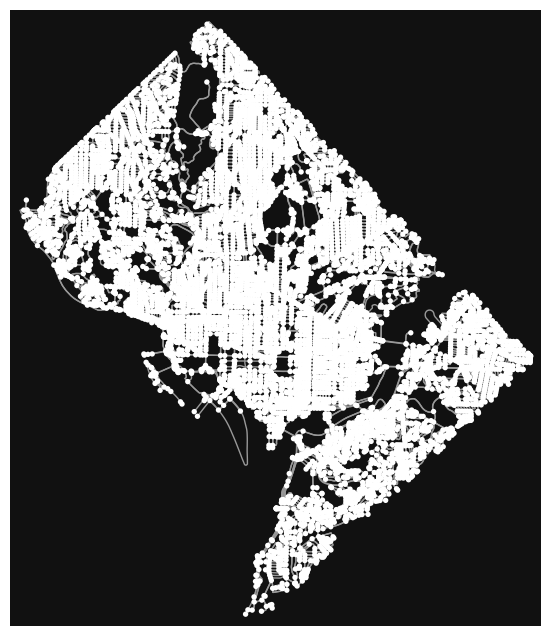

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [16]:
ox.plot_graph(dc_network_g)

In [26]:
dc_network_nodes.head()

,y,x,street_count,highway,ref,junction,geometry
osmid,,,,,,,
49184747,4.313438e+06,318180.695053,3,NaN,NaN,NaN,POINT (318180.695 4313437.873)
49198976,4.313487e+06,318231.640197,3,NaN,NaN,NaN,POINT (318231.64 4313486.593)
937305437,4.313432e+06,318174.083723,3,NaN,NaN,NaN,POINT (318174.084 4313431.674)
49786378,4.313435e+06,318303.801684,4,stop,NaN,NaN,POINT (318303.802 4313434.706)
49190879,4.316197e+06,325259.895265,3,NaN,NaN,NaN,POINT (325259.895 4316196.522)


## Load other data

In [20]:
# Load affordable housing points
affordable_housing = gpd.read_file('Affordable_Housing.geojson').to_crs(UTM18)

<Axes: >

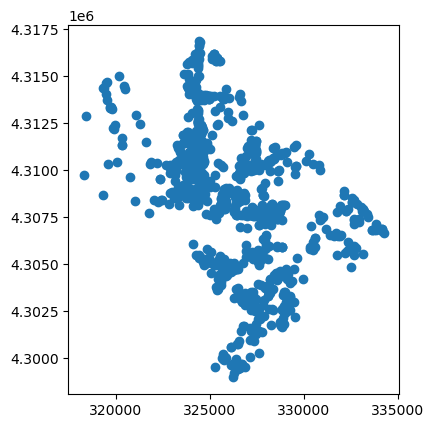

In [21]:
affordable_housing.plot()

In [22]:
# Load Metro Center point
metro_center = gpd.points_from_xy([-77.032774], [38.8985198])
metro_center = gpd.GeoDataFrame(geometry=metro_center, crs=WGS84).to_crs(epsg=UTM18)

<Axes: >

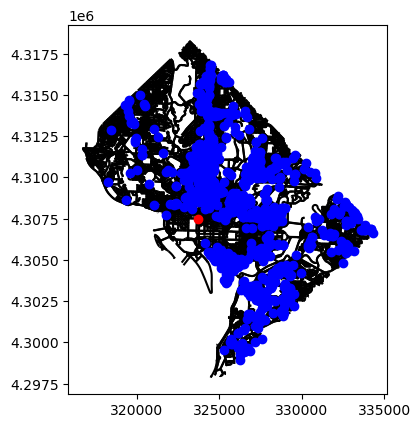

In [23]:
# Map data to make sure everything lines up
ax = dc_network_edges.plot(color='black', zorder=1)
affordable_housing.plot(ax=ax, color='blue', zorder=2)
metro_center.plot(ax=ax, color='red', zorder=3)

## Relate points to street network

In [24]:
# Find the nearest node to metro center
metro_center_nodes, metro_center_node_dists = ox.nearest_nodes(
    dc_network_g,
    metro_center.geometry.get_coordinates().x, 
    metro_center.geometry.get_coordinates().y, 
    return_dist=True)

In [25]:
metro_center_nodes

array([49745629])

In [28]:
dc_network_nodes.loc[49745629]

y                                            4307456.017836
x                                             323789.795446
street_count                                              4
highway                                     traffic_signals
ref                                                     NaN
junction                                                NaN
geometry        POINT (323789.7954457104 4307456.017836036)
Name: 49745629, dtype: object

In [ ]:
dc_network_edges.loc[49745629]

,,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,ref,bridge,junction,tunnel,width,access
v,key,,,,,,,,,,,,,,,
49745628,0,"[397316186, 397316195]",primary,"[6, 7]",NaN,14th Street Northwest,False,True,107.128129,"LINESTRING (323789.795 4307456.018, 323789.523...",NaN,NaN,NaN,NaN,NaN,NaN
876615362,0,397316204,primary,7,NaN,14th Street Northwest,False,False,115.203085,"LINESTRING (323789.795 4307456.018, 323790.039...",NaN,NaN,NaN,NaN,NaN,NaN
49762221,0,421290235,tertiary,2,NaN,G Street Northwest,False,False,144.627785,"LINESTRING (323789.795 4307456.018, 323774.051...",NaN,NaN,NaN,NaN,NaN,NaN
49762210,0,509466050,tertiary,2,NaN,G Street Northwest,False,True,201.865147,"LINESTRING (323789.795 4307456.018, 323805.71 ...",NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
metro_center_node_dists

array([74.35849321])

In [32]:
# Find the nearest nodes to affordable housing units
affordable_housing_nodes, affordable_housing_node_dists = ox.nearest_nodes(
    dc_network_g,
    affordable_housing.geometry.get_coordinates().x,
    affordable_housing.geometry.get_coordinates().y,
    return_dist=True)

In [35]:
affordable_housing_nodes[:5]

array([  49732176,   49780064, 7930223889, 7930223077,   49884831])

<Axes: >

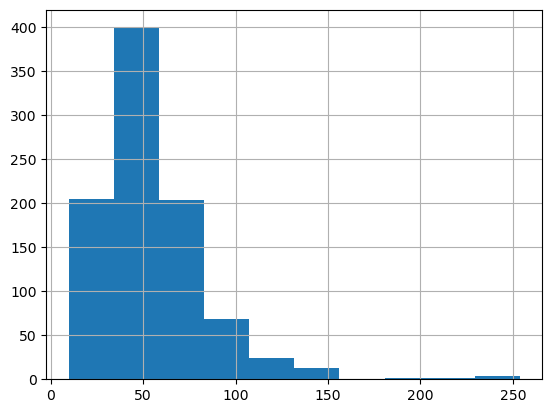

In [37]:
pd.Series(affordable_housing_node_dists).hist()

## Calculate shortest path

In [67]:
# Calculate shortest path between the first affordable housing project and metro center
affordable_housing_node = affordable_housing_nodes[0]
metro_center_node = metro_center_nodes[0]

route = ox.shortest_path(
    dc_network_g, 
    affordable_housing_node, 
    metro_center_node, 
    weight='length',
)

In [68]:
len(route)

66

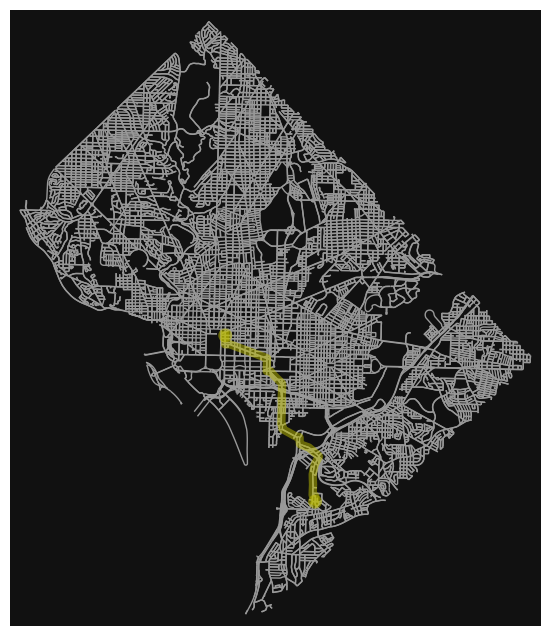

In [69]:
fig, ax = ox.plot_graph_route(dc_network_g, route, route_color="y", route_linewidth=6, node_size=0)

## Calculate travel time

In [70]:
# dc_network_edges.head()

In [63]:
# help(ox.add_edge_speeds)

In [71]:
# impute speed on all edges missing data
dc_network_g = ox.add_edge_speeds(dc_network_g)

# calculate travel time (seconds) for all edges
dc_network_g = ox.add_edge_travel_times(dc_network_g)

# Convert to geodataframes
dc_network_nodes, dc_network_edges = ox.graph_to_gdfs(dc_network_g)

In [72]:
# dc_network_edges

In [73]:
route = ox.shortest_path(
    dc_network_g, 
    affordable_housing_node, 
    metro_center_node, 
    weight='travel_time',
)

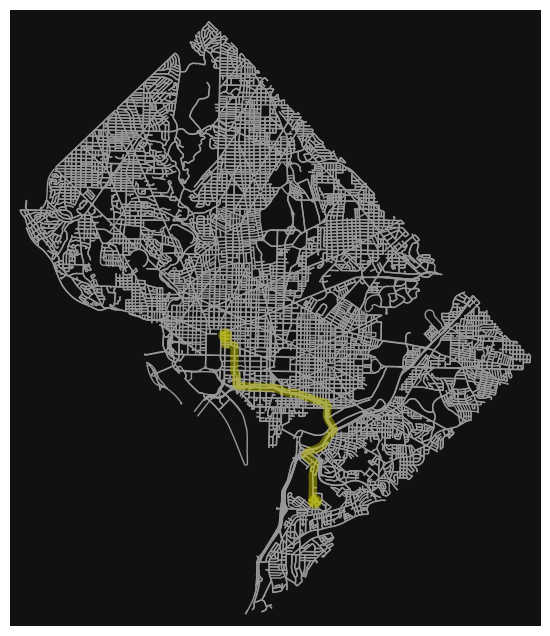

In [74]:
fig, ax = ox.plot_graph_route(dc_network_g, route, route_color="y", route_linewidth=6, node_size=0)

In [81]:
# Add up route time
ox.routing.route_to_gdf(dc_network_g, route)['travel_time'].sum()

np.float64(621.149340903604)

In [ ]:
# Add up route length
ox.routing.route_to_gdf(dc_network_g, route)['length'].sum()

np.float64(9440.91047575277)

## Loop calculations for bulk processing

In [83]:
def shortest_paths_to_metro_center(graph, o_nodes, d_node, weight='length'):    
    # Calculate shortest paths between each O-D pair
    d_nodes = [d_node] * len(o_nodes)
    routes = ox.shortest_path(graph, o_nodes, d_nodes, weight=weight)
    # Gather data for edges along each route
    combined_route_edges = []
    for route_id, route in enumerate(routes):
        route_edges = ox.routing.route_to_gdf(dc_network_g, route)
        route_edges['route_id'] = route_id
        combined_route_edges.append(route_edges)
    combined_route_edges = pd.concat(combined_route_edges, axis=0)
    # Sum length and travel time for edges involved with each route
    route_summaries = combined_route_edges.groupby('route_id')[['length','travel_time']].sum()
    # Clean up column names
    route_summaries = route_summaries.rename(columns={'length':'dist_to_metro_center', 'travel_time': 'time_to_metro_center'})
    return route_summaries
        
routes = shortest_paths_to_metro_center(
    dc_network_g, 
    affordable_housing_nodes, 
    metro_center_node, 
    weight='length'
)

routes.head()

,dist_to_metro_center,time_to_metro_center
route_id,,
0,7928.957103,686.276855
1,1979.256746,169.951887
2,8378.579379,731.371668
3,8300.334426,724.216660
4,9748.687894,801.560663


In [84]:
# Add distance and time estimates back to affordable housing df
affordable_housing = pd.concat([affordable_housing, routes], axis=1)

In [85]:
affordable_housing.head()

,OBJECTID,MAR_WARD,ADDRESS,PROJECT_NAME,STATUS_PUBLIC,AGENCY_CALCULATED,TOTAL_AFFORDABLE_UNITS,LATITUDE,LONGITUDE,AFFORDABLE_UNITS_AT_0_30_AMI,...,UNITS_NEWLY_COVENANT_EXISTING,AFFORDABLE_UNITS_PRODUCTION,UNITS_NET_NEW,UNITS_MARKET,UNITS_TOTAL,CONSTRUCTION_END_DATE,PLANNING_AREA,geometry,dist_to_metro_center,time_to_metro_center
0,382721,Ward 8,"2730 Martin Luther King Jr Avenue Southeast, W...","STE - Parcels 7, 8, & 9",Pipeline,DMPED,283.0,38.847109,-76.995377,50.0,...,0.0,283.0,283.0,12.0,307.0,2027-12-01 00:00:00+00:00,FAR SOUTHEAST AND SOUTHWEST,POINT (326837.595 4301702.915),7928.957103,686.276855
1,382722,Ward 2,"631 P Street Northwest, Washington, District o...",7th and P St NW,Pipeline,DMPED OP,29.0,38.909868,-77.021195,3.0,...,0.0,29.0,29.0,201.0,230.0,2027-12-31 00:00:00+00:00,NEAR NORTHWEST,POINT (324751.126 4308717.374),1979.256746,169.951887
2,382723,Ward 8,"1110 Oak Drive Southeast, Washington, District...",STE - St. Elizabeths Parcel 15,Pipeline,DMPED,151.0,38.846246,-76.990111,33.0,...,0.0,151.0,151.0,137.0,288.0,2027-06-01 00:00:00+00:00,FAR SOUTHEAST AND SOUTHWEST,POINT (327284.425 4301590.83),8378.579379,731.371668
3,382724,Ward 8,"1100 Alabama Avenue Southeast, Washington, Dis...",STE - Parcel 13,Pipeline,DMPED,126.0,38.848266,-76.988405,32.0,...,0.0,126.0,126.0,295.0,421.0,2028-01-01 00:00:00+00:00,FAR SOUTHEAST AND SOUTHWEST,POINT (327445.443 4301818.072),8300.334426,724.216660
4,382725,Ward 7,"726 51st Street Northeast, Washington, Distric...",726 51st St NE,Pipeline,DHCD,6.0,38.898990,-76.927789,0.0,...,0.0,6.0,6.0,40.0,46.0,NaT,FAR NORTHEAST AND SOUTHEAST,POINT (332825.088 4307334.777),9748.687894,801.560663


## Compare to straight line distance

In [86]:
affordable_housing['straight_dist_to_metro_center'] = affordable_housing.distance(metro_center.geometry.iloc[0])

In [87]:
affordable_housing.head()

,OBJECTID,MAR_WARD,ADDRESS,PROJECT_NAME,STATUS_PUBLIC,AGENCY_CALCULATED,TOTAL_AFFORDABLE_UNITS,LATITUDE,LONGITUDE,AFFORDABLE_UNITS_AT_0_30_AMI,...,AFFORDABLE_UNITS_PRODUCTION,UNITS_NET_NEW,UNITS_MARKET,UNITS_TOTAL,CONSTRUCTION_END_DATE,PLANNING_AREA,geometry,dist_to_metro_center,time_to_metro_center,straight_dist_to_metro_center
0,382721,Ward 8,"2730 Martin Luther King Jr Avenue Southeast, W...","STE - Parcels 7, 8, & 9",Pipeline,DMPED,283.0,38.847109,-76.995377,50.0,...,283.0,283.0,12.0,307.0,2027-12-01 00:00:00+00:00,FAR SOUTHEAST AND SOUTHWEST,POINT (326837.595 4301702.915),7928.957103,686.276855,6564.457184
1,382722,Ward 2,"631 P Street Northwest, Washington, District o...",7th and P St NW,Pipeline,DMPED OP,29.0,38.909868,-77.021195,3.0,...,29.0,29.0,201.0,230.0,2027-12-31 00:00:00+00:00,NEAR NORTHWEST,POINT (324751.126 4308717.374),1979.256746,169.951887,1611.655877
2,382723,Ward 8,"1110 Oak Drive Southeast, Washington, District...",STE - St. Elizabeths Parcel 15,Pipeline,DMPED,151.0,38.846246,-76.990111,33.0,...,151.0,151.0,137.0,288.0,2027-06-01 00:00:00+00:00,FAR SOUTHEAST AND SOUTHWEST,POINT (327284.425 4301590.83),8378.579379,731.371668,6883.749623
3,382724,Ward 8,"1100 Alabama Avenue Southeast, Washington, Dis...",STE - Parcel 13,Pipeline,DMPED,126.0,38.848266,-76.988405,32.0,...,126.0,126.0,295.0,421.0,2028-01-01 00:00:00+00:00,FAR SOUTHEAST AND SOUTHWEST,POINT (327445.443 4301818.072),8300.334426,724.216660,6777.569350
4,382725,Ward 7,"726 51st Street Northeast, Washington, Distric...",726 51st St NE,Pipeline,DHCD,6.0,38.898990,-76.927789,0.0,...,6.0,6.0,40.0,46.0,NaT,FAR NORTHEAST AND SOUTHEAST,POINT (332825.088 4307334.777),9748.687894,801.560663,9107.027545


<Axes: >

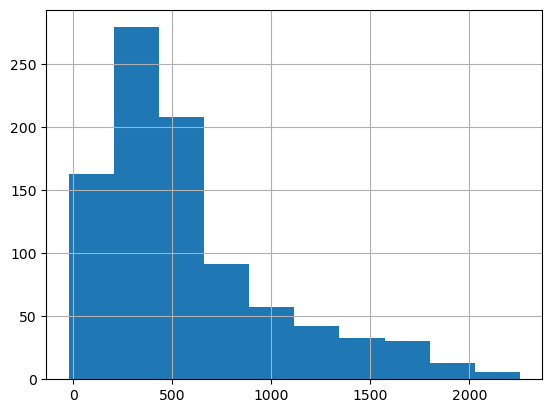

In [88]:
(affordable_housing['dist_to_metro_center'] - affordable_housing['straight_dist_to_metro_center']).hist()